# Stochastic Timestamps and Stochastic Sampling of Red/Blue Events Example

This example demonstrates how to generate a stochastic time series with stochastic events (being either red or blue), analyze the occurrences of these events in specified intervals, and visualize the results. <br>
**Please go through the example with deterministic events before trying this.** <br>

Be more specific... TBD

## Imports

In [50]:
import numpy as np
import logging

from EventStreamGenerator import EventTimestampGenerator, EventSampleSpace, EventStreamGenerator
from Analytics import plot_timeline_with_colors, count_number_of_occurrences_in_intervals

## Configure Logging

Logging is configured to show INFO level messages and above, with a specific format that includes the timestamp, logger name, log level, and message.

In [51]:
logger = logging.getLogger(__name__)

logging.basicConfig(
    level=logging.INFO,                            
    format="%(asctime)s %(name)s %(levelname)s: %(message)s",
)

## Configure Inputs

The inputs are configured for this example. Including:
- **max_time**: End boundary of intervals and maximum time the simulation will run
- **intervals**: 1 second intervals [(0, 1), (1, 2), (2, 3)]
- **occurrences**: The number of times the event are to occur in each interval [1, 2, 3]. This means that an event will occur once in the interval (0,1), twice in (1, 2) etc.
- **time_scaling**: This scales the time, if set to 1 it is outputting in real-time, and when set to 100 it runs 100 times faster than real-time.
- **event_handler**: This function is invoked with event details whenever an event is occurring.
  
And two new inputs for this example:
- **noise_sds**: Noise standard deviations - the standard deviations of the noises to be added to the samples, which is normally distributed with mean 0.
- **occurrence_noise_sds**: Occurrences Noise Standard Deviations - the standard deviations of the noises to be added to the "number of occurrences" samples, which is normally distributed with mean occurrences[i], for each interval i.

In [52]:
max_time = 3
intervals = [(i, i+1) for i in range(max_time)]
occurrences = [i+1 for i in range(max_time)]
time_scaling = 100 # 1 is real-time

print("Time intervals:", intervals)
print("Occurrences:", occurrences)

# Callback function to handle events
def event_handler(event):
    logger.info(f"New event: {event}")
    logger.info("--------")


# NEW INPUTS
# Event Noise Standard Deviation
__noise_sd = .5
noise_sds = [__noise_sd]*max_time

# Occurrence Noise Standard Deviation
__occurrence_noise_sd = 1
occurrence_noise_sds = [__occurrence_noise_sd]*max_time

print("Noise Standard Deviations:", noise_sds)
print("Occurrence Noise Standard Deviations:", occurrence_noise_sds)

Time intervals: [(0, 1), (1, 2), (2, 3)]
Occurrences: [1, 2, 3]
Noise Standard Deviations: [0.5, 0.5, 0.5]
Occurrence Noise Standard Deviations: [1, 1, 1]


## Define Event

In [53]:
class StochasticETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals, noise_sds, occurrences_sds):
        self.noise_sds = noise_sds
        self.occurrences_sds = occurrences_sds
        super().__init__(occurrences, time_intervals)
    
    # CHANGED THIS
    def sample_noise(self, i):
        return np.random.normal(loc=0, scale=self.noise_sds[i])
    
    # CHANGED THIS
    def sample_occurrences(self, occurrences_i, i):
        return int(np.round(np.random.normal(loc=occurrences_i, scale=self.occurrences_sds[i])))

class RedBlueSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
        self.values = ["red", "blue"]
        self.probabilities = [0.5, 0.5]

    def sample(self, t):
        return str(np.random.choice(self.values, p=self.probabilities))
    

etg = StochasticETG(occurrences, intervals, noise_sds, occurrence_noise_sds)
ess = RedBlueSampleSpace()
event = (etg, ess)

## Run Generator

In [54]:
# Initialize the TimeSeriesGenerator with the ETG and ESS
time_series_generator = EventStreamGenerator([event], event_handler)
# Run the generator to produce data for "max_time" time with a time-scaling of 100
data = time_series_generator.run(max_time, time_scaling)

# Log results
logger.info(f"Generated data: {data}")

2025-08-09 12:03:52,437 __main__ INFO: New event: (0.9714275372637886, 'red')
2025-08-09 12:03:52,437 __main__ INFO: --------
2025-08-09 12:03:52,438 __main__ INFO: New event: (0.9858207956023064, 'blue')
2025-08-09 12:03:52,438 __main__ INFO: --------
2025-08-09 12:03:52,439 __main__ INFO: New event: (0.9988432386578072, 'blue')
2025-08-09 12:03:52,439 __main__ INFO: --------
2025-08-09 12:03:52,439 __main__ INFO: New event: (1.0372386194831418, 'blue')
2025-08-09 12:03:52,440 __main__ INFO: --------
2025-08-09 12:03:52,440 __main__ INFO: New event: (1.3171850307615374, 'blue')
2025-08-09 12:03:52,440 __main__ INFO: --------


2025-08-09 12:03:52,453 __main__ INFO: New event: (2.6137150193694865, 'blue')
2025-08-09 12:03:52,454 __main__ INFO: --------
2025-08-09 12:03:52,456 __main__ INFO: New event: (2.938420931549609, 'red')
2025-08-09 12:03:52,457 __main__ INFO: --------
2025-08-09 12:03:52,457 __main__ INFO: New event: (2.976848985744814, 'blue')
2025-08-09 12:03:52,458 __main__ INFO: --------
2025-08-09 12:03:52,458 __main__ INFO: Generated data: [(0.9714275372637886, 'red'), (0.9858207956023064, 'blue'), (0.9988432386578072, 'blue'), (1.0372386194831418, 'blue'), (1.3171850307615374, 'blue'), (2.6137150193694865, 'blue'), (2.938420931549609, 'red'), (2.976848985744814, 'blue')]


## Analyse Results

In [55]:
count_number_of_occurrences_in_intervals(intervals, data)

[3, 2, 3]

## Plot Results

From running the plots multiple times, it is evident that the datapoints are altering between red and blue. 

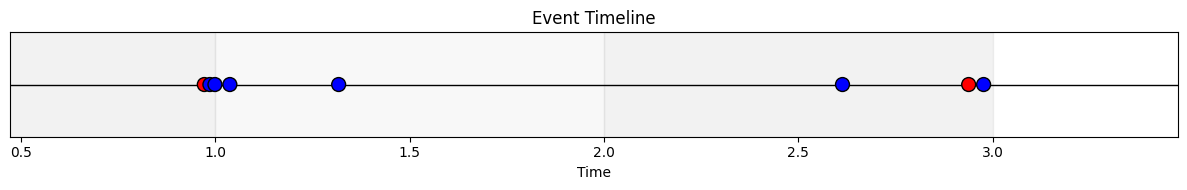

In [56]:
plot_timeline_with_colors(data, intervals)